# Minimizer statistics: FIRE, L-BFGS and CG on the sharp tier

Measurements intended for designing a new minimizer. Three questions organize the notebook:

1. At what step should FIRE hand off to a line-search method?
2. Does a schedule using both CG and L-BFGS beat one using either alone, and does the order matter?
3. How do the answers change with `N`, with `n`, and between the compliant and rigid formulations?

The minimizers run with their optional machinery disabled: no stall detector, no noise-floor warning,
no state dumps, no progress bars. Three stopping rules remain, a per-stage step budget, a total-energy
target and a `max|F|` target. Schedules are additionally timed against one another: the fastest run so
far sets the wall-clock allowance for the next, and a run that beats it replaces it.

## Two measurements to read first

The polygons fold during relaxation, and more so at higher vertex counts. The build is simple in every
case, so the relaxation is what folds them:

| n | `sum \|turn\|` at build | after 300 FIRE steps |
|---|---|---|
| 4 | 360.00 | 360.00 |
| 8 | 360.00 | 625.04 |
| 16 | 360.00 | 1028.77 |
| 32 | 360.00 | 1514.22 |

This is not specific to `phi = 1`; both formulations fold at phi = 1.00, 0.85, 0.70 and 0.55. The
resulting energies are small, of order 1e-26, partly because of it: a folded polygon's lobes cancel in
the overlap measure. The sharp tier contains no term penalizing self-intersection, as
`selfRepulsionEnergyForce` is wired into the mollified branch only.

What follows is therefore a comparison of three minimizers descending the same objective from the same
starting configuration under the same stopping rules. That comparison is sound. It does not support
conclusions about packing quality, and the feasibility table reports `simple` for every run, which is
False except at n = 4.

The second measurement concerns the GPU. The sharp CUDA kernel raises `CUDA error 700` during line
searches: 3 of 12 trial cells, all of them L-BFGS or CG, with FIRE not triggering it. The error leaves
the CUDA context unusable, so each run executes in a separate process, and a failed run is repeated on
the numpy path and marked. Timings from the two paths are not comparable.

In [1]:
import json
import os
import sys
import time

import numpy as np
from matplotlib import pyplot as plt

sys.path.insert(0, "tests")
import minimizerBenchmark as mb           # only buildSystem / runPlan / feasibility / runOne live there

# Fixed hue per minimizer, assigned in a constant order rather than cycled. Blue, orange and aqua are
# the first three slots of a palette validated for colorblind separation across all pairs in both
# light and dark modes. A fourth series would be given its own panel rather than a fourth hue.
COLORS = {"fire": "#2a78d6", "lbfgs": "#eb6834", "cg": "#1baf7a"}
LABELS = {"fire": "FIRE", "lbfgs": "L-BFGS", "cg": "CG"}

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.axisbelow": True, "font.size": 9})

## Running one configuration

Each run executes in a separate process. The sharp CUDA kernel can fail partway through a line search
with `CUDA error 700`, which leaves the context unusable for the remainder of the process; a failure
caught in-process would return values computed after that point, which are not trustworthy. A failed
run is reported with the outcome `crashed` and the child's stderr, then repeated on the numpy path and
marked with `fellBack`.

In [2]:
def planLabel(plan):
    """``[["fire", 100], ["lbfgs", 50]]`` -> ``"fire:100+lbfgs:50"``.

    A record that completes gets this label from ``runPlan`` inside the child. A record that crashed
    or timed out is assembled here from the spec instead, so it has to be labelled the same way --
    otherwise ``plan`` is a list on exactly the rows a failure produces, and every consumer that
    formats it raises."""
    return "+".join(f"{kind}:{steps}" for kind, steps in plan)


def runIsolated(spec, timeout = None):
    """Run ``mb.runOne(spec)`` in a child process. Returns its record, or one marked ``crashed``."""
    import subprocess
    command = [sys.executable, os.path.abspath(mb.__file__), "--spec", json.dumps(spec)]
    try:
        finished = subprocess.run(command, capture_output = True, text = True, timeout = timeout)
    except subprocess.TimeoutExpired:
        return dict(spec, plan = planLabel(spec["plan"]), outcome = "timeout", reached = False,
                    seconds = float(timeout or 0.0), maxForce = np.nan, energy = np.nan,
                    evaluations = 0, steps = 0)
    for line in reversed(finished.stdout.splitlines()):
        if line.startswith("{"):
            return json.loads(line)
    return dict(spec, plan = planLabel(spec["plan"]), outcome = "crashed", reached = False,
                seconds = np.nan, maxForce = np.nan, energy = np.nan, evaluations = 0, steps = 0,
                stderr = finished.stderr[-600:])


def runCell(spec, timeout = None, fallback = True):
    """One grid cell on the GPU, falling back to numpy if the kernel faults.

    The fallback is applied per configuration because the fault is intermittent and confined to the
    line-search methods: 3 of 12 trial cells faulted, all of them L-BFGS or CG. The strong-Wolfe line
    search evaluates trial points well outside the region a trajectory visits, and the kernel fails on
    that geometry."""
    record = runIsolated(dict(spec, device = "cuda"), timeout = timeout)
    record["device"] = "cuda"
    if fallback and record.get("outcome") == "crashed":
        record = runIsolated(dict(spec, device = "numpy"), timeout = timeout)
        record["device"] = "numpy"
        record["fellBack"] = True
    return record

## Parameters

`FORCE_TARGET` defines convergence for every schedule here. It is set above the measured force noise
floor of 3e-12. Below that floor the residual reflects floating-point arithmetic rather than the
configuration, so the time taken to reach it would be a measurement of rounding.

In [3]:
FORCE_TARGET = 1e-10
FIRE_BUDGET = 10000
LINE_BUDGET = 10000
PHI = 1.0
KAPPA = 4.0
SEED = 42

# Kept small until a per-configuration timing is available; the print below reports the grid size.
SWEEP_N = [4, 8, 16]
SWEEP_VERTICES = [4, 8, 16]
MODES = ["springs", "constrained"]

print(f"force target {FORCE_TARGET:.0e}  (noise floor 3e-12)")
print(f"budgets: FIRE {FIRE_BUDGET}, line search {LINE_BUDGET}")
print(f"grid: {len(SWEEP_N)} x {len(SWEEP_VERTICES)} x {len(MODES)} = "
      f"{len(SWEEP_N) * len(SWEEP_VERTICES) * len(MODES)} systems")

force target 1e-10  (noise floor 3e-12)
budgets: FIRE 10000, line search 10000
grid: 3 x 3 x 2 = 18 systems


## 1. Each minimizer alone

Baselines for the schedules that follow. Each minimizer runs alone with the full step budget from the
same starting configuration. No allowance is in place for the first run, so it establishes the one
used by the rest.

In [4]:
def race(specs, timeout = 900):
    """Run schedules in order, each given the best time recorded so far. Returns the records.

    The first schedule establishes the allowance, so the ordering affects how much compute is spent
    but not the ranking: a schedule stopped by the allowance had already exceeded the incumbent."""
    best = np.inf
    records = []
    for spec in specs:
        record = runCell(dict(spec, budget = best), timeout = timeout)
        records.append(record)
        if record.get("reached") and record["seconds"] < best:
            best = record["seconds"]
            print(f"  new best: {record['plan']} at {best:.2f} s")
    return records


def show(records):
    print(f"{'schedule':<26} {'device':<7} {'outcome':<9} {'seconds':>9} {'steps':>7} "
          f"{'evals':>8} {'ev/step':>8} {'max|F|':>10} {'energy':>11} {'simple':>7}")
    for r in records:
        f = r.get("feasibility") or {}
        steps = max(r.get("steps", 0), 1)
        plan = r.get("plan", "?")
        plan = plan if isinstance(plan, str) else planLabel(plan)
        print(f"{plan:<26} {r.get('device', '?'):<7} {r['outcome']:<9} "
              f"{r.get('seconds', float('nan')):>9.2f} {r.get('steps', 0):>7} "
              f"{r.get('evaluations', 0):>8} {r.get('evaluations', 0) / steps:>8.2f} "
              f"{r.get('maxForce', float('nan')):>10.2e} {r.get('energy', float('nan')):>11.3e} "
              f"{str(f.get('simple')):>7}")


base = dict(N = 8, n = 8, mode = "springs", phi = PHI, kappa = KAPPA, seed = SEED,
            forceTarget = FORCE_TARGET)
solo = race([dict(base, plan = [["fire", FIRE_BUDGET]]),
             dict(base, plan = [["lbfgs", LINE_BUDGET]]),
             dict(base, plan = [["cg", LINE_BUDGET]])])
show(solo)

  new best: lbfgs:10000 at 1.02 s
schedule                   device  outcome     seconds   steps    evals  ev/step     max|F|      energy  simple
fire:10000                 cuda    steps         12.37   10000    10200     1.02   3.30e-04   2.586e-06   False
lbfgs:10000                cuda    force          1.02     350      713     2.04   1.19e-14   7.365e-21   False
cg:10000                   cuda    timeout        1.78      50     1526    30.52   9.27e-03   9.562e-04   False


## 2. Convergence traces

`max|F|` against wall time. Step counts are not comparable across these methods, which cost different
numbers of force evaluations per step, so time is the axis to read.

Evaluations appear in a separate panel rather than on a second y-axis. A twin scale would place two
quantities of different units in one frame, where the point at which the curves cross is an artifact
of the scaling rather than a property of the data.

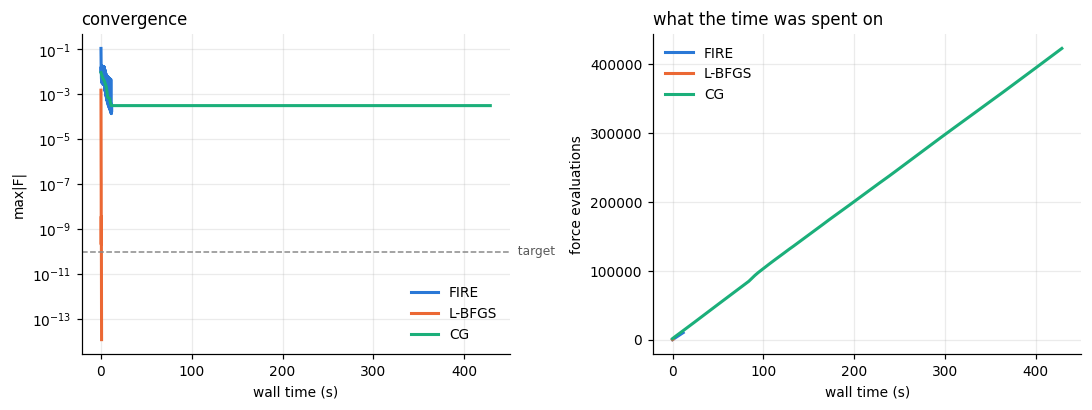

In [5]:
def trace(spec, timeout = 900):
    return runCell(dict(spec, keepTrace = True), timeout = timeout)


traces = {kind: trace(dict(base, plan = [[kind, FIRE_BUDGET if kind == "fire" else LINE_BUDGET]]))
          for kind in ("fire", "lbfgs", "cg")}

figure, (left, right) = plt.subplots(1, 2, figsize = (10, 3.8))
for kind, record in traces.items():
    rows = record.get("trace") or []
    if not rows:
        continue
    start = rows[0][2]
    seconds = [row[2] - start for row in rows]
    force = [row[4] for row in rows]
    evaluations = [row[5] for row in rows]
    left.semilogy(seconds, force, color = COLORS[kind], linewidth = 2, label = LABELS[kind])
    right.plot(seconds, evaluations, color = COLORS[kind], linewidth = 2, label = LABELS[kind])
left.axhline(FORCE_TARGET, color = "#8a8a8a", linewidth = 1, linestyle = "--")
left.text(left.get_xlim()[1], FORCE_TARGET, "  target", va = "center", fontsize = 8,
          color = "#5a5a5a")
left.set_xlabel("wall time (s)")
left.set_ylabel("max|F|")
left.set_title("convergence", loc = "left")
left.legend(frameon = False)
right.set_xlabel("wall time (s)")
right.set_ylabel("force evaluations")
right.set_title("what the time was spent on", loc = "left")
right.legend(frameon = False)
figure.tight_layout()
plt.show()

## 3. Where to hand off from FIRE

A binary search over the handoff step with the total budget fixed: FIRE runs for k steps and the
line-search method receives the remainder. The objective is the time to reach `FORCE_TARGET`, and a
schedule that does not reach it is ranked last.

The objective is not known to be unimodal in k, so this is a heuristic on a bracket rather than a
method guaranteed to locate an optimum, and the full history is returned with the best point.
A result at either end of the bracket indicates that the better schedule lies outside it, which
usually means one of the two minimizers does not belong in the schedule.

In [ ]:
def searchHandoff(spec, first, second, total, low = 0, high = None, rounds = 6, timeout = 900):
    """Binary search on the handoff step. Returns ``(best, history)``.

    ``first`` runs for k steps and ``second`` receives ``total - k``. The objective is time to the
    force target; a schedule that does not reach it is ranked as infinite."""
    high = int(total) if high is None else int(high)
    history = []

    def evaluate(k):
        plan = [stage for stage in ((first, int(k)), (second, int(total - k))) if stage[1] > 0]
        record = runCell(dict(spec, plan = plan), timeout = timeout)
        record["handoff"] = int(k)
        history.append(record)
        print(f"    handoff {k:>6}: {record['outcome']:<9} "
              f"{record.get('seconds', np.nan):>8.2f} s  "
              f"max|F| {record.get('maxForce', np.nan):.2e}  "
              f"{record.get('evaluations', 0):>7} evaluations")
        return record

    cost = lambda record: record["seconds"] if record.get("reached") else np.inf
    lowRecord, highRecord = evaluate(low), evaluate(high)
    for _ in range(int(rounds)):
        if high - low <= 1:
            break
        middle = (low + high) // 2
        middleRecord = evaluate(middle)
        # Retain the half containing the better endpoint. The objective is not known to be unimodal
        # in k, so this is a bracketed descent heuristic and the history is returned with the result.
        if cost(lowRecord) <= cost(highRecord):
            high, highRecord = middle, middleRecord
        else:
            low, lowRecord = middle, middleRecord
    return min(history, key = cost), history


handoffs = {}
for second in ("lbfgs", "cg"):
    print(f"\nFIRE -> {LABELS[second]}   (N = {base['N']}, n = {base['n']}, {base['mode']})")
    best, history = searchHandoff(base, "fire", second, total = FIRE_BUDGET)
    handoffs[second] = (best, history)
    print(f"  best: handoff {best['handoff']} -> {best['seconds']:.2f} s ({best['outcome']})")


FIRE -> L-BFGS   (N = 8, n = 8, springs)
    handoff      0: force         0.72 s  max|F| 3.98e-11      473 evaluations
    handoff  10000: steps        12.73 s  max|F| 1.72e-04    10200 evaluations
    handoff   5000: force         6.94 s  max|F| 1.96e-13     5813 evaluations
    handoff   2500: timeout     900.00 s  max|F| nan        0 evaluations
    handoff   1250: force         2.68 s  max|F| 6.13e-11     1950 evaluations
    handoff    625: force         2.35 s  max|F| 9.32e-13     1835 evaluations
    handoff    312: timeout     900.00 s  max|F| nan        0 evaluations
    handoff    156: force         1.81 s  max|F| 1.94e-14     1265 evaluations
  best: handoff 0 -> 0.72 s (force)

FIRE -> CG   (N = 8, n = 8, springs)
    handoff      0: steps       355.70 s  max|F| 1.19e-04   422678 evaluations
    handoff  10000: steps        10.29 s  max|F| 2.01e-04    10200 evaluations
    handoff   5000: steps       185.01 s  max|F| 8.40e-04   217850 evaluations
    handoff   2500: steps

In [ ]:
figure, axis = plt.subplots(figsize = (6.4, 3.8))
for second, (best, history) in handoffs.items():
    points = sorted((r["handoff"], r["seconds"] if r["reached"] else np.nan) for r in history)
    axis.plot([p[0] for p in points], [p[1] for p in points], "o-", markersize = 6,
              linewidth = 2, color = COLORS[second], label = f"FIRE -> {LABELS[second]}")
    axis.plot([best["handoff"]], [best["seconds"]], "o", markersize = 11,
              markerfacecolor = "none", markeredgewidth = 2, color = COLORS[second])
axis.set_xlabel("FIRE steps before the handoff")
axis.set_ylabel("time to target (s)")
axis.set_title("handoff sweep (open rings mark the best point)", loc = "left")
axis.legend(frameon = False)
figure.tight_layout()
plt.show()
print("gaps indicate schedules that did not reach the target.")

## 4. Using both line-search methods

Four schedules run against one another: FIRE followed by L-BFGS, FIRE followed by CG, and both
orderings of FIRE followed by CG and L-BFGS.

One caution in reading the table. If the second stage reaches `FORCE_TARGET`, the third stage never
runs, and the three-stage schedule is then the same trajectory as the two-stage one, with identical
timings and evaluation counts. Comparing the pairings requires capping the second stage below
convergence.

In [ ]:
split = handoffs["lbfgs"][0]["handoff"] or FIRE_BUDGET // 4
rest = max(FIRE_BUDGET - split, 100)
combined = race([
    dict(base, plan = [["fire", split], ["lbfgs", rest]]),
    dict(base, plan = [["fire", split], ["cg", rest]]),
    dict(base, plan = [["fire", split], ["cg", rest // 2], ["lbfgs", rest // 2]]),
    dict(base, plan = [["fire", split], ["lbfgs", rest // 2], ["cg", rest // 2]]),
])
show(combined)

## 5. Sweep over N and n

The full grid for both formulations, and the long-running section of the notebook. Each cell is a
separate process, so the sweep can be interrupted and resumed, and a CUDA failure costs one cell
rather than the run. Results are written to `data/minimizerSweep.json` as they complete.

In [ ]:
SWEEP_PATH = os.path.join(os.path.dirname(os.path.dirname(os.path.abspath(mb.__file__))),
                          "data", "minimizerSweep.json")


def sweep(schedule, label, path = SWEEP_PATH):
    """Run one schedule across the grid. Returns the records and writes them to ``path``.

    THE FILE IS REWRITTEN AFTER EVERY CONFIGURATION, not once at the end. This sweep is hours long,
    so a failure on the last cell -- or a kernel interrupt -- must not discard everything before it.
    The path is resolved from the package location rather than the working directory, because a
    notebook kernel's cwd is the notebook's own folder and a relative ``data/`` does not exist there."""
    os.makedirs(os.path.dirname(path), exist_ok = True)
    results = []
    for mode in MODES:
        for N in SWEEP_N:
            for n in SWEEP_VERTICES:
                spec = dict(N = N, n = n, mode = mode, phi = PHI, kappa = KAPPA, seed = SEED,
                            forceTarget = FORCE_TARGET, plan = schedule)
                start = time.time()
                record = runCell(spec, timeout = 1800)
                record["schedule"] = label
                results.append(record)
                f = record.get("feasibility", {})
                print(f"  {mode:<12} N={N:<3} n={n:<3} {record['outcome']:<9} "
                      f"{record.get('seconds', float('nan')):>8.2f} s  "
                      f"max|F| {record.get('maxForce', float('nan')):.2e}  "
                      f"simple {f.get('simple')}  {record.get('device')}"
                      f"{'  (fell back)' if record.get('fellBack') else ''}")
                with open(path, "w") as handle:
                    json.dump(results, handle, indent = 1)
    print(f"\n{len(results)} records written to {path}")
    return results


grid = sweep([["fire", split], ["lbfgs", rest]], "fire+lbfgs")

In [ ]:
# Time to target across the grid, as small multiples: one panel per formulation, one line per n.
# A sequential ramp (single hue, light to dark) encodes n, which is an ordered magnitude; the
# categorical hues remain reserved for the minimizers.
RAMP = ["#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]

figure, panels = plt.subplots(1, len(MODES), figsize = (5.0 * len(MODES), 3.8), sharey = True)
panels = np.atleast_1d(panels)
for panel, mode in zip(panels, MODES):
    for index, n in enumerate(SWEEP_VERTICES):
        rows = [r for r in grid if r.get("mode") == mode and r.get("n") == n]
        rows.sort(key = lambda r: r.get("N", 0))
        xs = [r["N"] for r in rows]
        ys = [r["seconds"] if r.get("reached") else np.nan for r in rows]
        panel.plot(xs, ys, "o-", linewidth = 2, markersize = 6,
                   color = RAMP[index % len(RAMP)], label = f"n = {n}")
    panel.set_title(mode, loc = "left")
    panel.set_xlabel("N polygons")
panels[0].set_ylabel("time to target (s)")
panels[0].legend(frameon = False, title = "vertices")
figure.tight_layout()
plt.show()
print("missing points did not reach the target within the budget.")

## 6. Feasibility

The checks that bound what the timings above can be used to claim. `simple` is False for every run
except at n = 4, which is the folding described at the start rather than a property of any particular
schedule. `worstEdgeError` is large in the springs formulation by construction, since the edges are
held by springs and are free to move.

In [ ]:
print(f"{'mode':<12} {'N':>3} {'n':>3} {'|turn|':>9} {'simple':>7} {'overlap':>11} "
      f"{'area err':>10} {'edge err':>10} {'max|C|':>9}")
for record in grid:
    f = record.get("feasibility") or {}
    if not f:
        print(f"{record.get('mode','?'):<12} {record.get('N',0):>3} {record.get('n',0):>3}   "
              f"(no feasibility -- {record['outcome']})")
        continue
    residual = f.get("maxResidual")
    print(f"{record.get('mode','?'):<12} {record.get('N',0):>3} {record.get('n',0):>3} "
          f"{f['turning']:>9.1f} {str(f['simple']):>7} {f['pairOverlap']:>11.2e} "
          f"{f['worstAreaError']:>10.2e} {f['worstEdgeError']:>10.2e} "
          f"{'--' if residual is None else f'{residual:.1e}':>9}")

## Notes for a new minimizer

Three quantities from the tables above bear on the design:

* the handoff step, and whether section 3 shows an interior optimum or returns a bracket boundary;
* evaluations per step, which is where CG and L-BFGS differ and is the cost a new method has to beat;
* how both quantities move with `n`. A handoff that drifts with vertex count needs a rule rather than
  a constant.

These results describe the rate of descent on this objective. Because every run converges by folding,
they do not describe packing quality.